<a href="https://colab.research.google.com/github/prathibha-15/cryptoarithmetic-puzzle/blob/master/DIABETES.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/early+stage+diabetes+risk+prediction+dataset.zip")

In [ ]:
df.shape

(520, 17)

In [ ]:
df.head(5)

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

MessageError: Error: credential propagation was unsuccessful

In [ ]:
df.tail(5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [ ]:
df.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


In [ ]:
df.isnull()

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
516,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
517,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
518,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le


df.head()


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.drop('class', axis=1)
y = df['class']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled)


[[-0.6613669   0.76509206 -0.99233705 ...  1.29099445  1.38022749
   2.21564684]
 [ 0.82136224  0.76509206 -0.99233705 ... -0.77459667  1.38022749
  -0.45133547]
 [-0.57899306  0.76509206  1.00772212 ...  1.29099445  1.38022749
  -0.45133547]
 ...
 [ 0.82136224 -1.30703226  1.00772212 ...  1.29099445 -0.72451824
   2.21564684]
 [-1.32035762 -1.30703226 -0.99233705 ... -0.77459667  1.38022749
  -0.45133547]
 [-0.49661921  0.76509206 -0.99233705 ... -0.77459667 -0.72451824
  -0.45133547]]


In [ ]:
mean_values = scaler.mean_
scale_values = scaler.scale_
print(mean_values)
print(scale_values)


[48.02884615  0.63076923  0.49615385  0.44807692  0.41730769  0.58653846
  0.45576923  0.22307692  0.44807692  0.48653846  0.24230769  0.45961538
  0.43076923  0.375       0.34423077  0.16923077]
[12.13977627  0.48259653  0.49998521  0.49729669  0.49311457  0.49245415
  0.4980398   0.41630951  0.49729669  0.49981875  0.42847949  0.49836641
  0.49518391  0.48412292  0.47511677  0.37495562]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

In [ ]:
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=20,          # Number of epochs
                    batch_size=32,      # Batch size
                    validation_split=0.2,  # Fraction of data used for validation
                    verbose=1)          # Verbosity level

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6778 - loss: 0.6132 - val_accuracy: 0.7976 - val_loss: 0.4884
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8159 - loss: 0.4904 - val_accuracy: 0.8571 - val_loss: 0.3863
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8855 - loss: 0.4096 - val_accuracy: 0.9048 - val_loss: 0.3102
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9141 - loss: 0.3310 - val_accuracy: 0.9405 - val_loss: 0.2513
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9433 - loss: 0.2502 - val_accuracy: 0.9405 - val_loss: 0.2057
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9204 - loss: 0.2299 - val_accuracy: 0.9286 - val_loss: 0.1756
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9573 - loss: 0.1547 - val_accuracy: 0.9286 - val_loss: 0.1500
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9388 - loss: 0.1505 - val_accuracy: 0.9286 - val_

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss}')
print(f'Test Accuracy: {accuracy}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9812 - loss: 0.0679
Test Loss: 0.07869866490364075
Test Accuracy: 0.9711538553237915


In [ ]:
y_pred = model.predict(X_test)

# Convert probabilities to class labels (for binary classification)
y_pred_classes = (y_pred > 0.5).astype(int)



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [ ]:
from sklearn.metrics import confusion_matrix,classification_report

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
print(cm)

[[32  1]
 [ 2 69]]


In [ ]:
cr=classification_report(y_test,y_pred_classes)
print(cr)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96        33
           1       0.99      0.97      0.98        71

    accuracy                           0.97       104
   macro avg       0.96      0.97      0.97       104
weighted avg       0.97      0.97      0.97       104



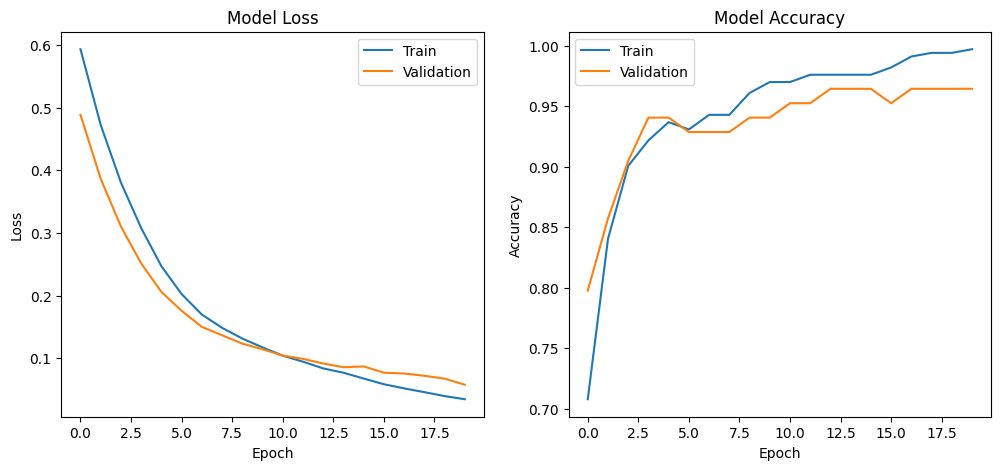

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
import tensorflow as tf
model.save('deep_neural_network_model.h5')


In [ ]:

%%writefile app.py
import streamlit as st
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the trained model
model = tf.keras.models.load_model('deep_neural_network_model.h5')

# Load and preprocess the dataset
df = pd.read_csv('/content/drive/MyDrive/early+stage+diabetes+risk+prediction+dataset.zip')

# Encode categorical variables
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

# Split features and target
X = df.drop('class', axis=1)
y = df['class']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Streamlit App
st.title('Deep Neural Network Classifier')

# Sidebar for user input features
st.sidebar.header('User Input Features')
def user_input_features():
    features = {}
    for i, col in enumerate(X.columns):
        features[col] = st.sidebar.number_input(col, value=0.0)
    return pd.DataFrame(features, index=[0])

input_data = user_input_features()

# Display input data
st.subheader('User Input Data')
st.write(input_data)

# Scale the input data
input_data_scaled = scaler.transform(input_data)
st.subheader('Scaled Input Data')
st.write(input_data_scaled)

# Make prediction
prediction = model.predict(input_data_scaled)
predicted_class = (prediction > 0.5).astype(int)

st.subheader('Prediction')
st.write('Predicted Probability:', prediction[0][0])
st.write('Predicted Class:', 'Positive' if predicted_class[0][0] == 1 else 'Negative')

# Evaluate the model on test data
st.subheader('Model Evaluation')
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

# Confusion Matrix
st.write('Confusion Matrix:')
cm = confusion_matrix(y_test, y_pred_classes)
st.write(cm)

# Classification Report
st.write('Classification Report:')
report = classification_report(y_test, y_pred_classes, output_dict=True)
st.write(pd.DataFrame(report).transpose())

# ROC Curve
st.subheader('ROC Curve')
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
st.pyplot(plt)

# Precision-Recall Curve
st.subheader('Precision-Recall Curve')
precision, recall, _ = precision_recall_curve(y_test, y_pred)
average_precision = average_precision_score(y_test, y_pred)
plt.figure()
plt.plot(recall, precision, lw=2, label=f'Average precision = {average_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
st.pyplot(plt)

# Display accuracy
accuracy = accuracy_score(y_test, y_pred_classes)
st.write(f'Accuracy: {accuracy}')


Writing app.py


In [ ]:
pip install streamlit


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!ngrok authtoken 2l9B7n4uHLcheLwEQlwEsHWpgOV_29qHfzREXjtEPbP6yxZz7


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(f"Streamlit app is live at: {public_url}")


Streamlit app is live at: NgrokTunnel: "https://b418-34-28-230-110.ngrok-free.app" -> "http://localhost:8501"


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.28.230.110


In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
! streamlit run app.py & npx localtunnel --port 8501

Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
Need to install the following packages:
  localtunnel@2.0.2
Ok to proceed? (y) ^C


In [ ]:
!pip install streamlit pyngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.9/82.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling tenacity-9.0.0:
      Successfully uninstalled tenacity-9.0.0


In [ ]:
from pyngrok import ngrok


In [ ]:
!streamlit run app.py &

In [ ]:
public_url = ngrok.connect(port='8501')
print(f'Public URL: {public_url}')

ERROR:pyngrok.process.ngrok:t=2024-08-25T10:21:54+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2024-08-25T10:21:54+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2024-08-25T10:21:54+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.